In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import seaborn as sns

### Data Loading

In [2]:

train_dir = "FER2013/Train"
test_dir = "FER2013/Test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

### Exploratory Data Analysis

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


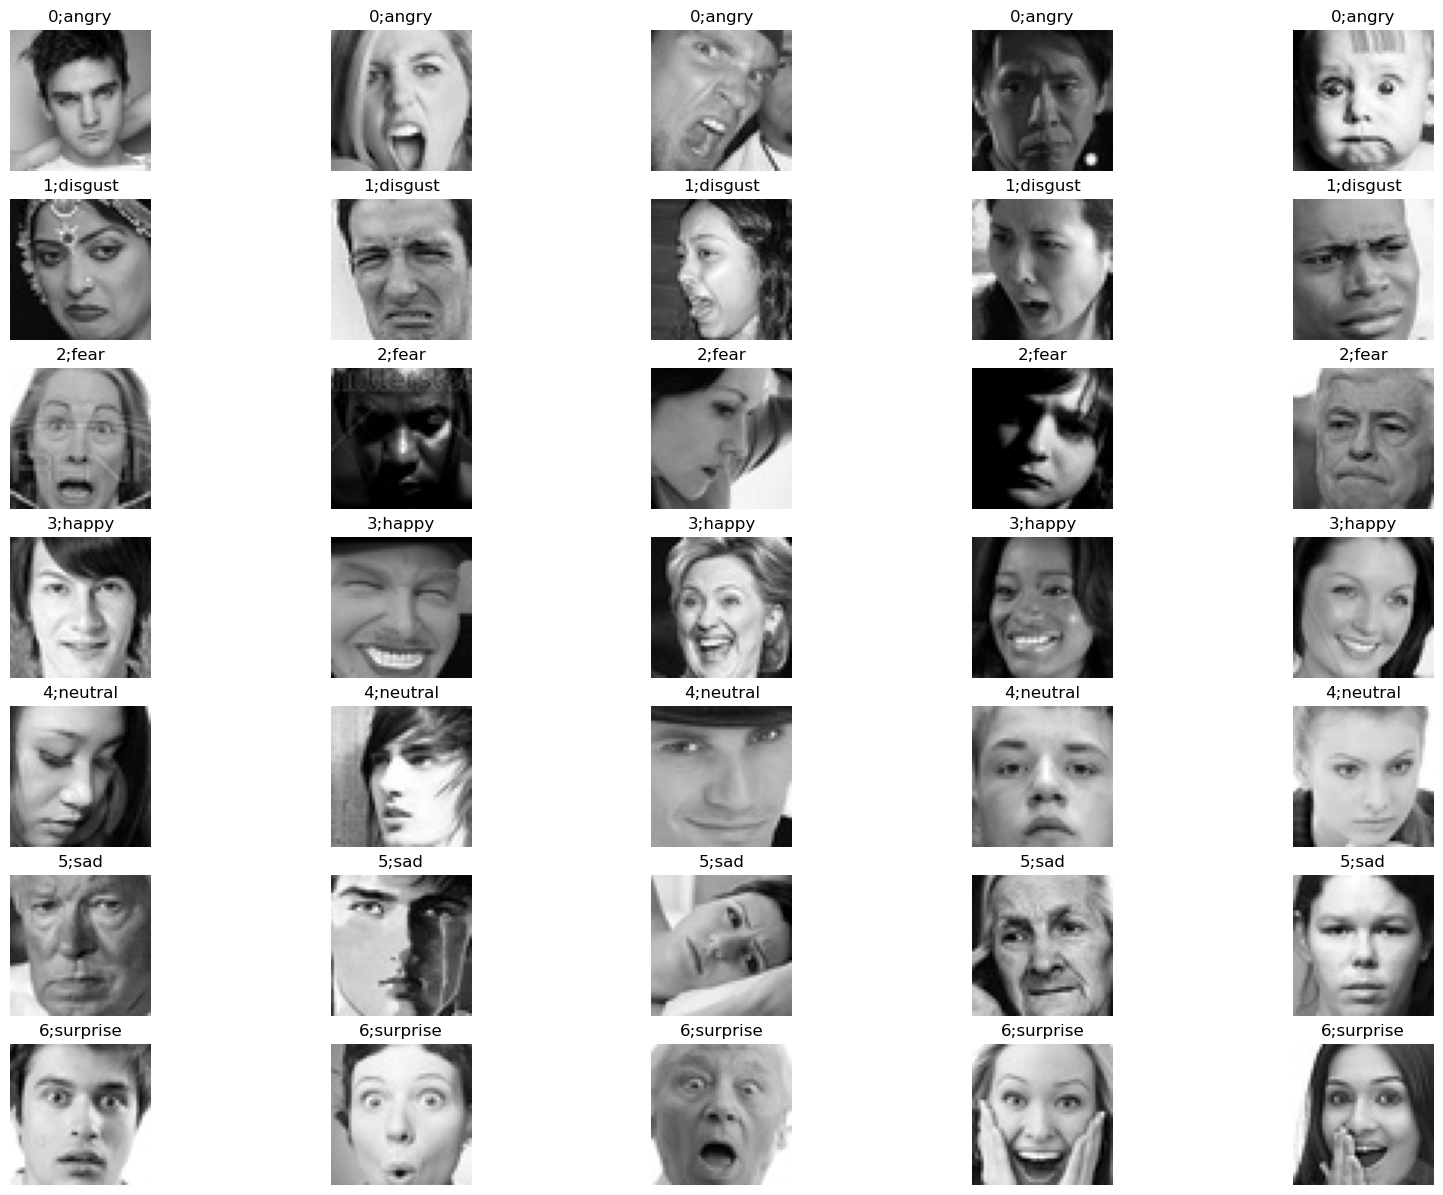

In [3]:
class_names = train_dataset.classes
print("Classes:", class_names)

def plot_images(dataset, num_images=5):
    dataloader = DataLoader(dataset,batch_size=1000,shuffle=True)
    class_names = train_dataset.classes
    fig, axes = plt.subplots(len(class_names),num_images, figsize=(20,15))
    images, labels = next(iter(dataloader))
    for i in range(len(class_names)):
        tmp = images[labels==i]
        for j in range(num_images):
            image = tmp[j]
            label = i
            axes[i,j].imshow(image.squeeze(), cmap="gray")
            axes[i,j].set_title(f"{label};{class_names[label]}")
            axes[i,j].axis("off")
    plt.show()

plot_images(train_dataset)

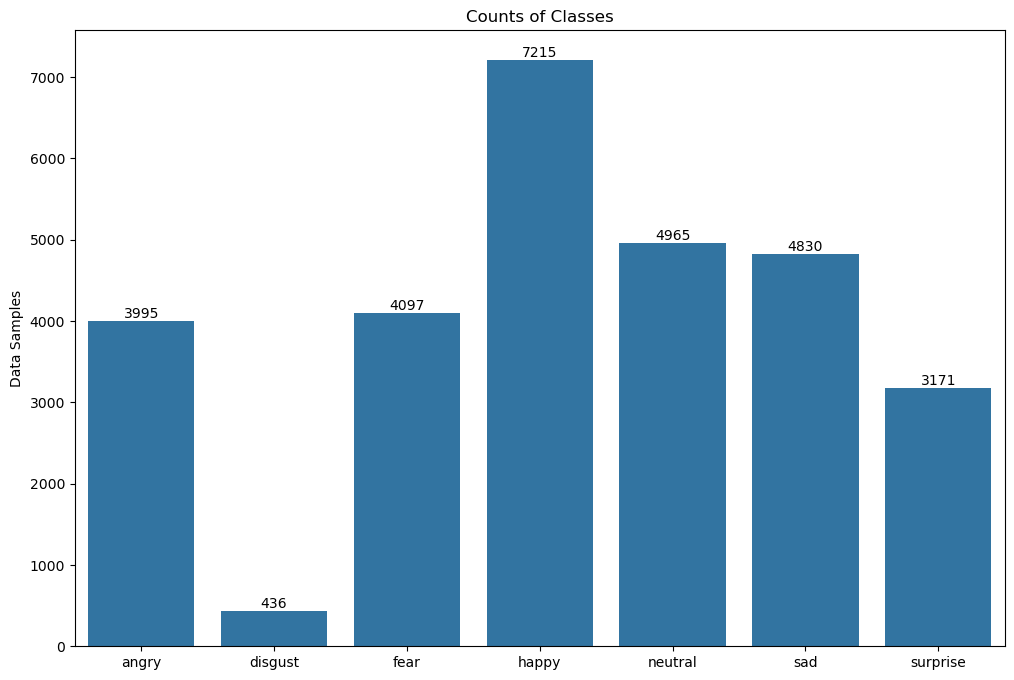

In [4]:
labels = [label for _,label in train_dataset]
labels = np.array(labels)
classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(12,8))
ax = sns.barplot(y = counts, x = class_names)
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

plt.ylabel("Data Samples")
plt.title("Counts of Classes")
plt.show()

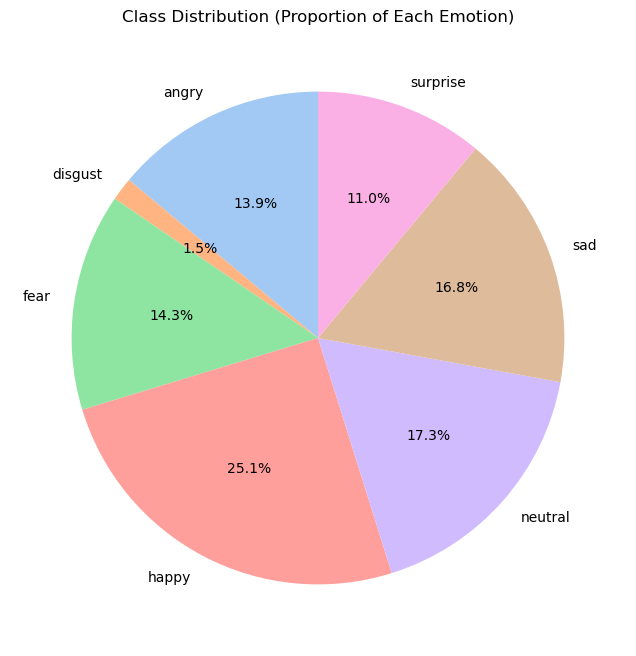

In [5]:
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Class Distribution (Proportion of Each Emotion)")
plt.show()

In [6]:
mean_count = np.mean(counts)
median_count = np.median(counts)
std_count = np.std(counts)

print(f"Mean count of samples per class: {mean_count:.2f}")
print(f"Median count of samples per class: {median_count:.2f}")
print(f"Standard deviation of samples per class: {std_count:.2f}")

Mean count of samples per class: 4101.29
Median count of samples per class: 4097.00
Standard deviation of samples per class: 1900.50


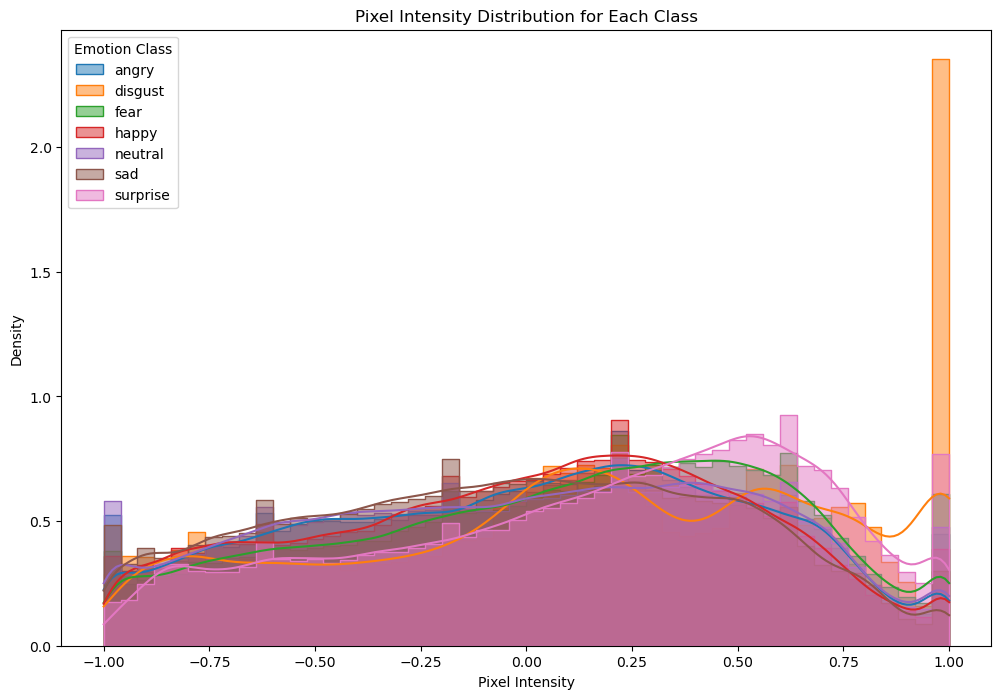

In [7]:
def plot_intensity_distribution(dataset):
    dataloader = DataLoader(dataset, batch_size=1000, shuffle=True)
    images, labels = next(iter(dataloader))
    images = images.numpy().squeeze()
    
    plt.figure(figsize=(12, 8))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == i]
        pixel_values = class_images.flatten()
        sns.histplot(pixel_values, kde=True, bins=50, label=class_name, element="step", stat="density")
    
    plt.title("Pixel Intensity Distribution for Each Class")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Density")
    plt.legend(title="Emotion Class")
    plt.show()

plot_intensity_distribution(train_dataset)

#### Sample Creation

In [8]:
import os
from torchvision.transforms import functional as F
from torchvision.utils import save_image


augmentation = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5)
])

augmented_dir = os.path.join(train_dir, "disgust_augmented")
os.makedirs(augmented_dir, exist_ok=True)


disgust_class_path = os.path.join(train_dir, "disgust")
disgust_images = [os.path.join(disgust_class_path, img) for img in os.listdir(disgust_class_path)]


target_count = 2000
current_count = len(disgust_images)
augment_count = max(0, target_count - current_count)

print(f"Generating {augment_count} augmented images for the 'disgust' class...")

for i in range(augment_count):
    img_path = np.random.choice(disgust_images)
    img = plt.imread(img_path)
    img = torch.tensor(img).unsqueeze(0).float() / 255.0
    

    augmented_img = augmentation(img)
   
   
    aug_img_path = os.path.join(augmented_dir, f"augmented_{i}.png")
    save_image(augmented_img, aug_img_path)

print(f"Augmentation complete. Augmented images saved to '{augmented_dir}'.")


Generating 1564 augmented images for the 'disgust' class...
Augmentation complete. Augmented images saved to 'FER2013/Train\disgust_augmented'.


In [13]:

train_dir = "FER2013/Train"
test_dir = "FER2013/Test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

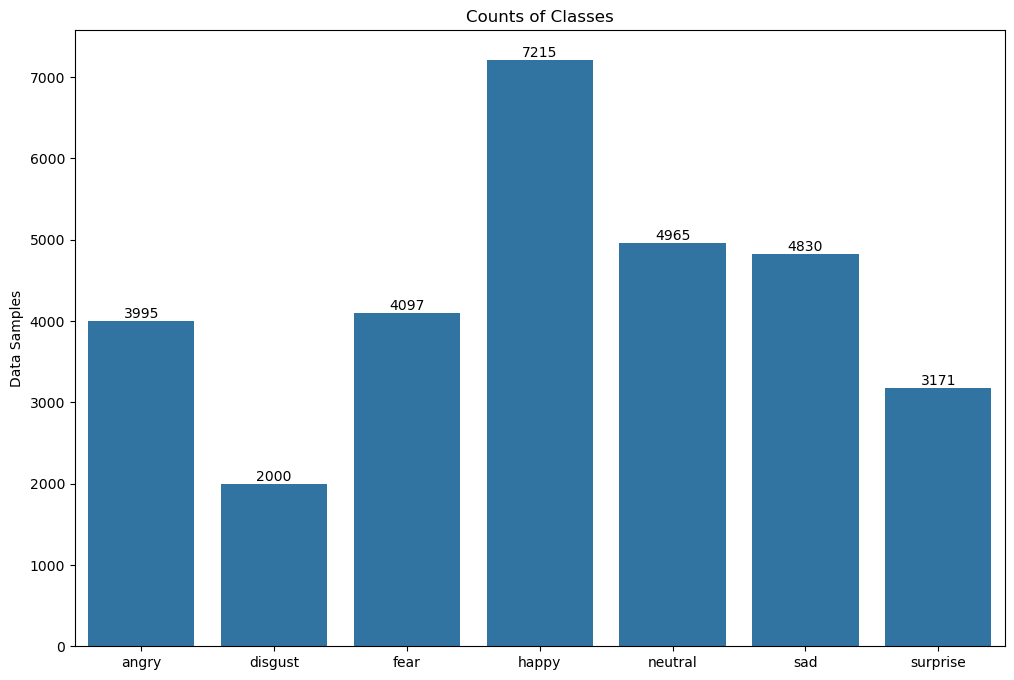

In [14]:
labels = [label for _,label in train_dataset]
labels = np.array(labels)
classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(12,8))
ax = sns.barplot(y = counts, x = class_names)
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

plt.ylabel("Data Samples")
plt.title("Counts of Classes")
plt.show()

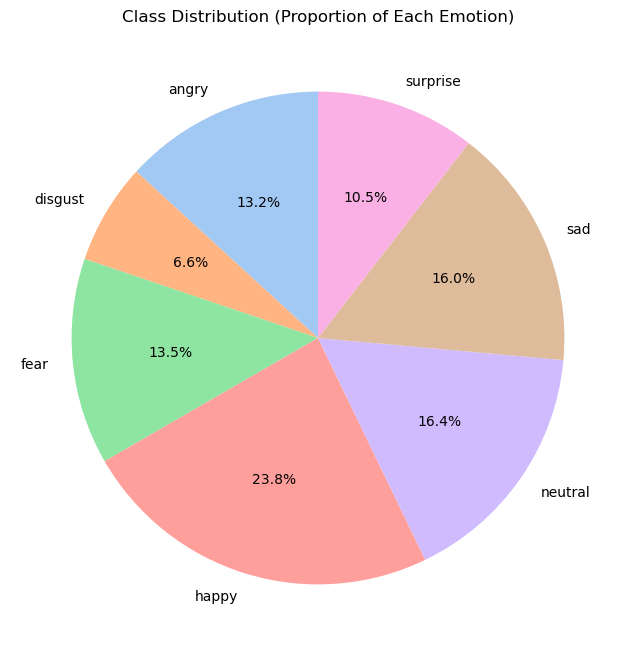

In [15]:
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Class Distribution (Proportion of Each Emotion)")
plt.show()

### Pre Baseline

In [2]:
from torch.utils.data.sampler import SubsetRandomSampler

train_dir = "FER2013/Train"
test_dir = "FER2013/Test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

num_train = len(train_dataset)
idx = list(range(num_train))
valid_size = 0.2
np.random.shuffle(idx)
split_idx = int(np.floor(num_train*valid_size))
train_idx, valid_idx = idx[split_idx:], idx[:split_idx]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler,num_workers=2)
valid_loader = DataLoader(train_dataset,batch_size=batch_size,sampler=valid_sampler,num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=2)

## Baseline

In [9]:
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, input_size=48*48, num_classes=7):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 200)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(200, 100)
        self.fc4 = nn.Linear(100, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu2(self.fc3(x))
        x = self.fc4(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

In [10]:
from torchsummary import summary

images, _ = next(iter(train_loader))
images = images.view(images.size(0),-1)
input_shape = images.shape[1:]
print('Input Shape: ',input_shape)
summary(mlp_model,input_shape)

Input Shape:  torch.Size([2304])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]       1,180,160
              ReLU-2                  [-1, 512]               0
            Linear-3                  [-1, 200]         102,600
              ReLU-4                  [-1, 200]               0
            Linear-5                  [-1, 100]          20,100
              ReLU-6                  [-1, 100]               0
            Linear-7                    [-1, 7]             707
Total params: 1,303,567
Trainable params: 1,303,567
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.01
Params size (MB): 4.97
Estimated Total Size (MB): 4.99
----------------------------------------------------------------


In [11]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=10):
    
    acc = []
    validation_acc = []
    train_loss = []
    val_loss = []

    for epoch in range(num_epochs):
        
        model.train()

        total_loss = 0
        num_data = 0
        correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            

            _,predicted = torch.max(outputs,1)
            correct = (predicted==labels).sum().item() + correct
            num_data += labels.size(0)

        train_acc = correct/num_data*100

        model.eval()

        valid_total_loss = 0
        num_data = 0
        correct = 0

        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            valid_loss = criterion(outputs,labels)
            valid_total_loss += valid_loss.item()
            
            _,predicted = torch.max(outputs,1)
            correct = (predicted==labels).sum().item() + correct
            num_data += labels.size(0)
        
        val_acc = correct/num_data*100


        acc.append(train_acc)
        validation_acc.append(val_acc)
        train_loss.append(total_loss/len(train_loader))
        val_loss.append(valid_total_loss/len(valid_loader))

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {valid_total_loss/len(valid_loader): .4f}")
        print(f"Train Accuracy: {train_acc: .4f}, Val Accuracy: {val_acc: .4f}")
        print(f"----------------")


    history = [acc,validation_acc,train_loss,val_loss]
    
    return model, history

In [12]:
mlp, history = train_model(mlp_model, train_loader, valid_loader, criterion, optimizer)

Epoch [1/10]
Train Loss: 1.6460, Val Loss:  1.5551
Train Accuracy:  35.1129, Val Accuracy:  38.5695
----------------
Epoch [2/10]
Train Loss: 1.5126, Val Loss:  1.5484
Train Accuracy:  41.3683, Val Accuracy:  39.6267
----------------
Epoch [3/10]
Train Loss: 1.4401, Val Loss:  1.4936
Train Accuracy:  44.4940, Val Accuracy:  41.7245
----------------
Epoch [4/10]
Train Loss: 1.3669, Val Loss:  1.5001
Train Accuracy:  47.2728, Val Accuracy:  42.1374
----------------
Epoch [5/10]
Train Loss: 1.2997, Val Loss:  1.5024
Train Accuracy:  49.7708, Val Accuracy:  42.0383
----------------
Epoch [6/10]
Train Loss: 1.2272, Val Loss:  1.4874
Train Accuracy:  53.1318, Val Accuracy:  44.1857
----------------
Epoch [7/10]
Train Loss: 1.1471, Val Loss:  1.5716
Train Accuracy:  55.9437, Val Accuracy:  43.7397
----------------
Epoch [8/10]
Train Loss: 1.0714, Val Loss:  1.5990
Train Accuracy:  59.0611, Val Accuracy:  42.9468
----------------
Epoch [9/10]
Train Loss: 0.9903, Val Loss:  1.6637
Train Accurac

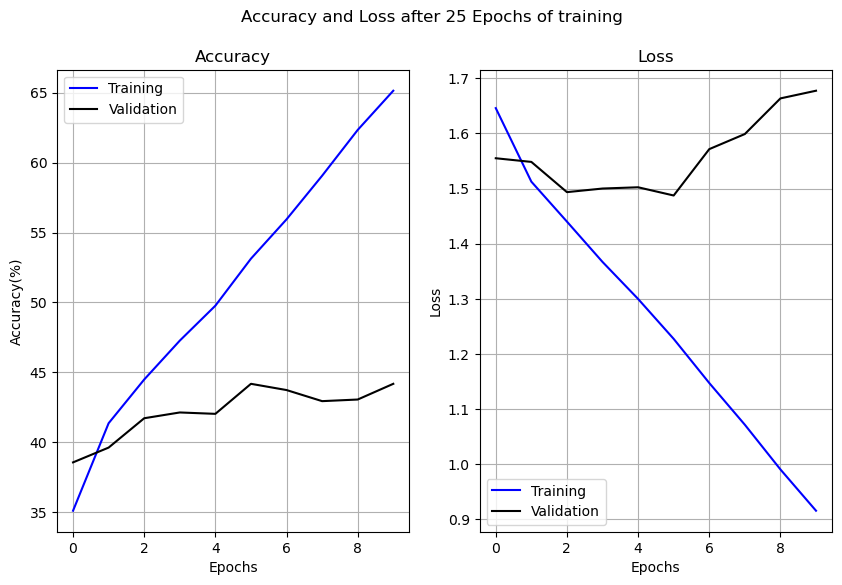

In [13]:
def history_plotter(history):

    num_epochs = 10
    acc = history[0]
    validation_acc = history[1]
    train_loss = history[2]
    val_loss = history[3]

    fig, ax = plt.subplots(1,2,figsize=(10,6))
    fig.suptitle("Accuracy and Loss after 25 Epochs of training")

    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy(%)")
    ax[0].set_title("Accuracy")
    ax[0].plot(range(num_epochs),acc,color='b',label='Training')
    ax[0].plot(range(num_epochs),validation_acc,color='k',label='Validation')
    ax[0].legend()
    ax[0].grid()

    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].set_title("Loss")
    ax[1].plot(range(num_epochs),train_loss,color='b',label='Training')
    ax[1].plot(range(num_epochs),val_loss,color='k',label='Validation')
    ax[1].legend()
    ax[1].grid()

history_plotter(history)

In [18]:
# total_correct = 0
# total_loss = 0
# num_data = 0

# for images, labels in test_loader:
#     images, labels = images.to(device), labels.to(device)
#     outputs = mlp(images)
#     valid_loss = criterion(outputs,labels)
#     total_loss += valid_loss.item()

#     _,predicted = torch.max(outputs,1)
#     total_correct= (predicted==labels).sum().item() + total_correct
#     num_data += labels.size(0)

# print(f"Test Accuracy:{total_correct/num_data*100: .4f}%")
# print(f"Test Loss:{total_loss/num_data: .4f}")

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import numpy as np

mlp.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = mlp(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"✅ Test Accuracy:{accuracy_score(all_labels, all_preds)*100: 0.4f}%")
print("\n📊 Classification Report:\n", classification_report(all_labels, all_preds))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
confusion_matrix = confusion_matrix(all_labels, all_preds)


✅ Test Accuracy: 43.0343%

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.24      0.29       958
           1       0.21      0.22      0.21       111
           2       0.31      0.32      0.32      1024
           3       0.56      0.63      0.59      1774
           4       0.36      0.42      0.39      1233
           5       0.34      0.32      0.33      1247
           6       0.62      0.56      0.59       831

    accuracy                           0.43      7178
   macro avg       0.40      0.39      0.39      7178
weighted avg       0.43      0.43      0.43      7178


🧩 Confusion Matrix:
 [[ 232   15  141  180  164  182   44]
 [  21   24   13   16   19   13    5]
 [  87   12  328  147  181  176   93]
 [  88   23  138 1117  214  141   53]
 [  75   20  124  225  523  217   49]
 [ 106   18  187  232  266  401   37]
 [  28    4  119   87   77   52  464]]


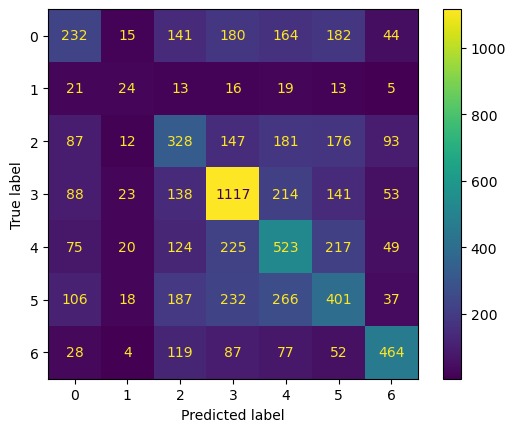

In [16]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1, 2, 3, 4, 5, 6])
cm_display.plot()
plt.show()